In [9]:
#!/usr/bin/env python3
import os
import csv
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from beeswarm import *

In [10]:
ypf1601 = csv.reader(open('1601_module_sizes_mod.tsv'), delimiter='\t', skipinitialspace=True)
ypf1604 = csv.reader(open('1604_module_sizes_mod.tsv'), delimiter='\t', skipinitialspace=True)
ypf1608 = csv.reader(open('1608_module_sizes_mod.tsv'), delimiter='\t', skipinitialspace=True)
ypf1618 = csv.reader(open('1618_module_sizes_mod.tsv'), delimiter='\t', skipinitialspace=True)
ypf1610 = csv.reader(open('1610_module_sizes_mod.tsv'), delimiter='\t', skipinitialspace=True)
ypf1621 = csv.reader(open('1621_module_sizes_mod.tsv'), delimiter='\t', skipinitialspace=True)
papillatum = csv.reader(open('Dpap_modules.tsv'), delimiter='\t', skipinitialspace=True)
ambulator = csv.reader(open('Damb_modules.tsv'), delimiter='\t', skipinitialspace=True)
flectonema = csv.reader(open('Fner_modules.tsv'), delimiter='\t', skipinitialspace=True)
rhyneul = csv.reader(open('Reul_modules.tsv'), delimiter='\t', skipinitialspace=True)
hemistasia = csv.reader(open('Hpha_modules.tsv'), delimiter='\t', skipinitialspace=True)

def get_cmap(n, name='viridis'): #hsv for very divergent data?
	'''Returns a function that maps each index in 0, 1, ..., n-1 to a distinct 
	RGB color; the keyword argument name must be a standard mpl colormap name.'''
	colormap = plt.cm.get_cmap(name, n)
	rgbcolors = []
	for i in range(colormap.N):
		rgb = colormap(i)[:3] # will return rgba, we take only first 3 so we get rgb
		rgbcolors.append(matplotlib.colors.rgb2hex(rgb))
	return rgbcolors

def csv_parser(file):
	module_list = []
	for row in file:
		module_list.append(int(row[1]))
	return module_list


In [11]:
llan = csv_parser(ypf1601)
djap = csv_parser(ypf1604)
rhum = csv_parser(ypf1608)
sspe = csv_parser(ypf1618)
ypf10 = csv_parser(ypf1610)
ypf21 = csv_parser(ypf1621)
dpap = csv_parser(papillatum)
damb = csv_parser(ambulator)
fner = csv_parser(flectonema)
reul = csv_parser(rhyneul)
hpha = csv_parser(hemistasia)

# module sizes in each species
y = [damb, djap, dpap, rhum, reul, llan, fner, sspe, ypf10, hpha, ypf21]
#list of species
x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]



In [20]:
data = []
for i in y:
	data.append(np.array(i))

boxprops = dict(linestyle='--', linewidth=1, color='black')
medianprops = dict(linestyle='--', linewidth=2.5, color='black')
whiskerprops = dict(color='black')

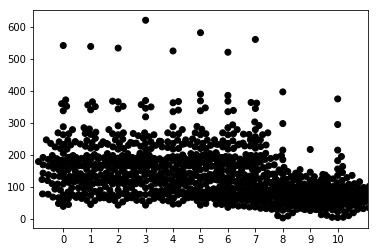

In [5]:
#bplot = beeswarm(data)

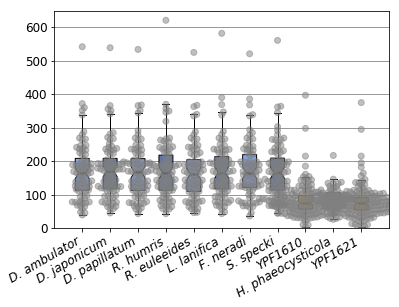

In [21]:

bplot = beeswarm(data, method='swarm', positions=x, s=7, col='grey', alpha=0.5, zorder=10)
bplot = plt.boxplot(data, notch=True, patch_artist=True, showfliers=False, boxprops=boxprops, medianprops=medianprops, \
	whiskerprops=whiskerprops)

#or define: ['pink', 'lightblue', 'lightgreen']
# colors = get_cmap(len(x))

colors = ['#87a8ee', '#5e75a6', '#87a8ee', '#5e75a6', '#87a8ee', '#5e75a6', '#87a8ee', '#5e75a6', \
	'#ffa500', '#ffc04c', '#ffa500'] 
for patch, color in zip(bplot['boxes'], colors):
	patch.set_facecolor(color)

# #overlapping points
# for xe, ye in zip(x, y):
# 	 plt.plot([xe] * len(ye), ye, 'o', mfc='none', c='black', zorder=10)

plt.xticks(x)
plt.xlim(0, 12)
plt.axes().set_xticklabels(['D. ambulator', 'D. japonicum','D. papillatum', 'R. humris', 'R. euleeides', \
	'L. lanifica', 'F. neradi', 'S. specki', 'YPF1610', 'H. phaeocysticola', 'YPF1621'], fontstyle='italic', \
	fontsize=12, rotation=30, horizontalalignment='right')
plt.ylim(0, 650)
plt.axes().set_yticklabels([0, 100, 200, 300, 400, 500, 600], fontsize=12)
plt.grid(which='major', axis='y', linestyle='-', color='grey')

plt.show()
